In [1]:
#@title # Model #7: 1D Graph (ESM-2 node features + sequence-adjacency edges) + GraphSAGE
# =============================================================================
# Part of the InterPET ablation table:
#   1. 1D, ESM-2, XGBoost   (already done)
#   2. 1D, ESM-2, RF        (already done)
#   3. 1D, ProtT5, XGBoost  (already done)
#   4. 1D, ProtT5, RF       (already done)
#   5. 1D, AAC/CTD, XGBoost (already done)
#   6. 1D, AAC/CTD, RF      (already done)
#   7. 1D, Graph (chain edges), GraphSAGE   <- this notebook
#   8. 1D+3D, Graph (structure contact-map edges), GraphSAGE
#
# Model #7 is the "no 3D" baseline of the two GNN variants: each residue is
# a graph node (feature = ESM-2 PER-RESIDUE embedding, not mean-pooled like
# Model #1-4), and edges connect ONLY sequence-adjacent residues (i <-> i+1)
# -- i.e. a simple chain graph that encodes no tertiary structure
# information. This is the graph-based analogue of "1D" in the ablation
# table: same idea as Model #1-6 (sequence-derived information only), just
# with a GNN instead of a tabular classifier. Cell/section structure
# (checkpointing, interpretability, mutagenesis) mirrors Model #1 as
# closely as the GNN methodology allows, for easy side-by-side reading.
#
# Model #8 (separate notebook) uses the SAME node features and the SAME
# subset of sequences, but replaces the chain edges with a 3D structural
# contact map (CA-CA distance < 8A), so that comparing Model #7 vs #8
# isolates the value added by 3D structural information for the GNN --
# analogous to how Model #1-6 isolate embedding choice and classifier
# choice.


In [2]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount('/content/drive')

# No Biopython/PDB parsing needed for Model #7 -- chain edges only depend
# on sequence length, not on 3D structure. (Model #8 needs Biopython.)
!pip install -q transformers accelerate tqdm pandas numpy scikit-learn shap seaborn
!pip install -q torch_geometric


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.1 MB/s eta 0:00:00


In [3]:
#@title # 1. Configuration

import os
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
STRUCT_DIR = os.path.join(PROJECT_ROOT, "structures")
MODEL_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model7_1d_graph_chain")
GRAPH_CACHE_DIR = os.path.join(MODEL_OUT_DIR, "graph_cache")
os.makedirs(GRAPH_CACHE_DIR, exist_ok=True)

STRUCTURE_METADATA_CSV = os.path.join(STRUCT_DIR, "structure_metadata_merged.csv")

ESM2_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"  # same as Model #1/#2
MAX_SEQ_LEN = 500          # consistent with MAX_STRUCT_LEN in the structure acquisition notebook
VAL_FRACTION = 0.15        # internal early-stopping validation fraction, stratified by label
N_FOLDS = 5
RANDOM_SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Structure metadata: {STRUCTURE_METADATA_CSV}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if not os.path.exists(STRUCTURE_METADATA_CSV):
    raise FileNotFoundError(f"{STRUCTURE_METADATA_CSV} not found. Run the Structure Acquisition notebook first.")


Device: cuda
Structure metadata: /content/drive/MyDrive/InterPET/structures/structure_metadata_merged.csv


In [4]:
#@title # 2. Load curated dataset (structure-matched subset)

df_meta = pd.read_csv(STRUCTURE_METADATA_CSV)
print(f"Total rows in structure metadata: {len(df_meta)}")

has_file = df_meta["file_path"].apply(lambda p: isinstance(p, str) and os.path.exists(p))
n_missing = (~has_file).sum()
if n_missing > 0:
    print(f"[WARNING] {n_missing} rows have no resolvable structure file -- these will be excluded "
          f"so that Model #7 and Model #8 are trained/evaluated on the exact same sequence subset.")
df_meta = df_meta[has_file].reset_index(drop=True)

print(f"\nUsable rows (structure file present): {len(df_meta)}")
print(df_meta.groupby(["split", "label"]).size())
print("\nStructure source breakdown:")
print(df_meta["structure_source"].value_counts(dropna=False))


Total rows in structure metadata: 1076

Usable rows (structure file present): 1076
split      label
benchmark  0        117
           1         22
train      0        534
           1        403
dtype: int64

Structure source breakdown:
structure_source
ESMFold_predicted    855
PDB_experimental     221
Name: count, dtype: int64


In [5]:
#@title # [OPTIONAL] Resume from checkpoint -- skip cells 5-8 below if you already trained once
# If you already ran sections 3-6 (Extract features / Hyperparameter search /
# Threshold optimization / Train final model) in a PREVIOUS session and the
# checkpoint files below still exist on Drive, run THIS cell instead of
# cells 5-8 -- it reloads everything needed and lets you jump straight to
# cell 9 ("7. Additional imports") without repeating any ESM-2 embedding
# extraction or GNN training.
#
# If this is your FIRST run (or the checkpoint files don't exist yet), just
# skip this cell and run cells 5-8 normally -- they create the checkpoint
# automatically at the end of cell 7 (Train final model).

import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

CHECKPOINT_PATH = os.path.join(MODEL_OUT_DIR, "full_checkpoint.pkl")
FINAL_MODEL_PATH = os.path.join(MODEL_OUT_DIR, "gnn_chain_edge_final.pt")
GRAPH_ARTIFACTS_PATH = os.path.join(GRAPH_CACHE_DIR, "graph_artifacts.pkl")

if os.path.exists(CHECKPOINT_PATH) and os.path.exists(FINAL_MODEL_PATH) and os.path.exists(GRAPH_ARTIFACTS_PATH):
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv, global_mean_pool
    from transformers import AutoTokenizer, EsmModel

    with open(GRAPH_ARTIFACTS_PATH, "rb") as f:
        artifacts = pickle.load(f)
    with open(CHECKPOINT_PATH, "rb") as f:
        ckpt = pickle.load(f)

    best_params = ckpt["best_params"]
    EDGE_KEY = ckpt["EDGE_KEY"]
    IN_CHANNELS = ckpt["IN_CHANNELS"]
    train_ids_all = ckpt["train_ids_all"]
    bench_ids = ckpt["bench_ids"]
    y_train_full = ckpt["y_train_full"]
    y_bench = ckpt["y_bench"]
    oof_proba = ckpt["oof_proba"]
    oof_pred = ckpt["oof_pred"]
    thresholds = ckpt["thresholds"]
    f1_scores = ckpt["f1_scores"]
    best_threshold = ckpt["best_threshold"]
    fold_metrics_df = ckpt["fold_metrics_df"]
    y_bench_proba = ckpt["y_bench_proba"]
    y_bench_pred = ckpt["y_bench_pred"]
    bench_metrics = ckpt["bench_metrics"]

    BATCH_SIZE = 16  # must match the value used in sections 4-6

    class PETaseGNN(nn.Module):
        def __init__(self, in_channels, hidden_channels=128, num_layers=2, dropout=0.5):
            super().__init__()
            self.convs = nn.ModuleList([SAGEConv(in_channels, hidden_channels)])
            for _ in range(num_layers - 1):
                self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.dropout = dropout
            self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
            self.fc2 = nn.Linear(hidden_channels // 2, 1)

        def pool_embedding(self, x, edge_index, batch):
            for conv in self.convs:
                x = F.relu(conv(x, edge_index))
                x = F.dropout(x, p=self.dropout, training=self.training)
            return global_mean_pool(x, batch)

        def forward(self, x, edge_index, batch):
            pooled = self.pool_embedding(x, edge_index, batch)
            h = F.relu(self.fc1(pooled))
            h = F.dropout(h, p=self.dropout, training=self.training)
            return self.fc2(h).squeeze(-1)

    def make_data_list(ids, edge_key):
        return [Data(x=artifacts[i]["x"], edge_index=artifacts[i][edge_key],
                      y=torch.tensor([artifacts[i]["y"]], dtype=torch.float)) for i in ids]

    @torch.no_grad()
    def predict_probs(model, ids, edge_key, batch_size=BATCH_SIZE):
        model.eval()
        loader = DataLoader(make_data_list(ids, edge_key), batch_size=batch_size, shuffle=False)
        all_logits, all_labels = [], []
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            all_logits.append(logits.cpu())
            all_labels.append(batch.y.cpu())
        logits = torch.cat(all_logits).numpy()
        labels = torch.cat(all_labels).numpy()
        return 1 / (1 + np.exp(-logits)), labels

    final_model = PETaseGNN(in_channels=IN_CHANNELS, **best_params).to(device)
    final_model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
    final_model.eval()

    # Needed later for the ESM-2-based mutagenesis scan (sections 17-18)
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

    @torch.no_grad()
    def get_per_residue_embedding(sequence, max_len=MAX_SEQ_LEN):
        seq = sequence[:max_len]
        inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = esm2_model(**inputs)
        hidden = out.last_hidden_state[0]
        residue_emb = hidden[1:1 + len(seq)]
        return residue_emb.cpu(), seq

    print("Resumed successfully from checkpoint:")
    print(f"  best_params      : {best_params}")
    print(f"  best_threshold   : {best_threshold:.2f}")
    print(f"  benchmark metrics: {bench_metrics}")
    print("\nYou can now skip directly to cell 9 ('7. Additional imports for visualization & interpretability').")
else:
    print("No checkpoint found yet -- run cells 5-8 normally first. They will create the "
          "checkpoint automatically at the end of cell 8 (Train final model).")


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Resumed successfully from checkpoint:
  best_params      : {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.3}
  best_threshold   : 0.44
  benchmark metrics: {'accuracy': 0.9640287769784173, 'precision': 0.84, 'recall': 0.9545454545454546, 'f1': 0.8936170212765957, 'auc': np.float64(0.9825174825174825), 'pr_auc': np.float64(0.8547580131694913), 'mcc': np.float64(0.8746581746004226)}

You can now skip directly to cell 9 ('7. Additional imports for visualization & interpretability').


In [ ]:
#@title # 3. Extract ESM-2 per-residue embeddings & build chain-edge graphs

from transformers import AutoTokenizer, EsmModel

print(f"Loading {ESM2_MODEL_NAME}...")
esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()


@torch.no_grad()
def get_per_residue_embedding(sequence, max_len=MAX_SEQ_LEN):
    """Return per-residue embedding [L, D] (L = sequence length after
    truncation), with special tokens (CLS/EOS) stripped -- unlike Model
    #1/#2, this is NOT mean-pooled, since the GNN needs one feature vector
    per node/residue."""
    seq = sequence[:max_len]
    inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out = esm2_model(**inputs)
    hidden = out.last_hidden_state[0]       # (L+2, D) -- includes CLS at position 0, EOS at the end
    residue_emb = hidden[1:1 + len(seq)]    # drop CLS & EOS, keep exactly len(seq) rows
    return residue_emb.cpu(), seq            # seq is also returned since it may have been truncated


GRAPH_ARTIFACTS_PATH = os.path.join(GRAPH_CACHE_DIR, "graph_artifacts.pkl")

artifacts = {}
if os.path.exists(GRAPH_ARTIFACTS_PATH):
    with open(GRAPH_ARTIFACTS_PATH, "rb") as f:
        artifacts = pickle.load(f)
    print(f"Resuming from checkpoint: {len(artifacts)} graphs already built.")

n_new = 0
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc="Building chain-edge graphs"):
    seq_id = row["id"]
    if seq_id in artifacts:
        continue

    sequence = row["sequence"]
    node_emb, seq_used = get_per_residue_embedding(sequence)
    L = len(seq_used)

    # Chain edges: connect ONLY sequence-adjacent residues (i <-> i+1).
    # This encodes no 3D information -- the "1D" control for Model #8.
    chain_src = list(range(L - 1)) + list(range(1, L))
    chain_dst = list(range(1, L)) + list(range(L - 1))
    edge_index_chain = torch.tensor([chain_src, chain_dst], dtype=torch.long)

    artifacts[seq_id] = {
        "x": node_emb,                  # (L, D) float tensor -- ESM-2 per-residue embedding
        "edge_index_chain": edge_index_chain,
        "sequence": seq_used,
        "y": int(row["label"]),
        "split": row["split"],
        "seq_len": L,
    }
    n_new += 1
    if n_new % 50 == 0:
        with open(GRAPH_ARTIFACTS_PATH, "wb") as f:
            pickle.dump(artifacts, f)

with open(GRAPH_ARTIFACTS_PATH, "wb") as f:
    pickle.dump(artifacts, f)

print(f"\nTotal graphs available: {len(artifacts)} ({n_new} newly built this run)")

train_ids_all = np.array([i for i, a in artifacts.items() if a["split"] == "train"])
bench_ids = np.array([i for i, a in artifacts.items() if a["split"] == "benchmark"])
y_train_full = np.array([artifacts[i]["y"] for i in train_ids_all])
y_bench = np.array([artifacts[i]["y"] for i in bench_ids])
IN_CHANNELS = artifacts[train_ids_all[0]]["x"].shape[1]

print(f"Train: {len(train_ids_all)} ({y_train_full.sum()} positive), "
      f"Benchmark: {len(bench_ids)} ({y_bench.sum()} positive)")
print(f"Node feature dimension (ESM-2): {IN_CHANNELS}")


Loading facebook/esm2_t30_150M_UR50D...


Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Resuming from checkpoint: 1076 graphs already built.


Building chain-edge graphs: 100%|██████████| 1076/1076 [00:00<00:00, 26695.72it/s]



Total graphs available: 1076 (0 newly built this run)
Train: 937 (403 positive), Benchmark: 139 (22 positive)
Node feature dimension (ESM-2): 640


In [ ]:
#@title # 4. Hyperparameter search (Stratified K-Fold CV)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

EDGE_KEY = "edge_index_chain"

# GNN training is much more expensive per fit than XGBoost/RF, so this
# search uses a SMALL grid and a REDUCED epoch budget (SEARCH_MAX_EPOCHS /
# SEARCH_PATIENCE) to keep total runtime tractable. The final model in
# section 6 is retrained with the FULL epoch budget.
param_grid = [
    {"hidden_channels": 64,  "num_layers": 2, "dropout": 0.3},
    {"hidden_channels": 128, "num_layers": 2, "dropout": 0.5},
    {"hidden_channels": 128, "num_layers": 3, "dropout": 0.5},
    {"hidden_channels": 64,  "num_layers": 3, "dropout": 0.3},
]

BATCH_SIZE = 16
SEARCH_MAX_EPOCHS, SEARCH_PATIENCE = 40, 8
FINAL_MAX_EPOCHS, FINAL_PATIENCE = 100, 15
LEARNING_RATE, WEIGHT_DECAY = 1e-3, 1e-4


class PETaseGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList([SAGEConv(in_channels, hidden_channels)])
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, 1)

    def pool_embedding(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return global_mean_pool(x, batch)

    def forward(self, x, edge_index, batch):
        pooled = self.pool_embedding(x, edge_index, batch)
        h = F.relu(self.fc1(pooled))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc2(h).squeeze(-1)  # logit


def make_data_list(ids, edge_key):
    return [Data(x=artifacts[i]["x"], edge_index=artifacts[i][edge_key],
                  y=torch.tensor([artifacts[i]["y"]], dtype=torch.float)) for i in ids]


@torch.no_grad()
def predict_probs(model, ids, edge_key, batch_size=BATCH_SIZE):
    model.eval()
    loader = DataLoader(make_data_list(ids, edge_key), batch_size=batch_size, shuffle=False)
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    return 1 / (1 + np.exp(-logits)), labels


def train_gnn(train_ids, val_ids, edge_key, in_channels, params, max_epochs, patience):
    train_loader = DataLoader(make_data_list(train_ids, edge_key), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(make_data_list(val_ids, edge_key), batch_size=BATCH_SIZE, shuffle=False)

    model = PETaseGNN(in_channels=in_channels, **params).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    n_pos = sum(artifacts[i]["y"] for i in train_ids)
    n_neg = len(train_ids) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_f1, best_state, patience_counter = -1, None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch.x, batch.edge_index, batch.batch), batch.y)
            loss.backward()
            optimizer.step()

        val_probs, val_labels = predict_probs(model, val_ids, edge_key)
        val_f1 = f1_score(val_labels, (val_probs >= 0.5).astype(int), zero_division=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_f1


skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

best_params, best_cv_f1 = None, -1
cv_results_log = []

for params in param_grid:
    fold_f1s = []
    for tr_idx, va_idx in skf.split(train_ids_all, y_train_full):
        tr_ids = train_ids_all[tr_idx]
        va_ids = train_ids_all[va_idx]
        inner_train_ids, inner_val_ids = train_test_split(
            tr_ids, test_size=VAL_FRACTION,
            stratify=[artifacts[i]["y"] for i in tr_ids], random_state=RANDOM_SEED,
        )
        model, _ = train_gnn(inner_train_ids, inner_val_ids, EDGE_KEY, IN_CHANNELS, params,
                              SEARCH_MAX_EPOCHS, SEARCH_PATIENCE)
        fold_probs, fold_labels = predict_probs(model, va_ids, EDGE_KEY)
        fold_f1s.append(f1_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))

    mean_f1 = np.mean(fold_f1s)
    cv_results_log.append({**params, "cv_f1_mean": mean_f1, "cv_f1_std": np.std(fold_f1s)})
    print(f"  params={params} -> CV F1 = {mean_f1:.4f} (+/- {np.std(fold_f1s):.4f})")

    if mean_f1 > best_cv_f1:
        best_cv_f1 = mean_f1
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best CV F1: {best_cv_f1:.4f}")

pd.DataFrame(cv_results_log).to_csv(os.path.join(MODEL_OUT_DIR, "cv_hyperparam_search.csv"), index=False)


  params={'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.3} -> CV F1 = 0.9319 (+/- 0.0356)
  params={'hidden_channels': 128, 'num_layers': 2, 'dropout': 0.5} -> CV F1 = 0.9147 (+/- 0.0259)
  params={'hidden_channels': 128, 'num_layers': 3, 'dropout': 0.5} -> CV F1 = 0.9164 (+/- 0.0333)
  params={'hidden_channels': 64, 'num_layers': 3, 'dropout': 0.3} -> CV F1 = 0.9304 (+/- 0.0320)

Best params: {'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.3}
Best CV F1: 0.9319


In [ ]:
#@title # 5. Threshold optimization via OUT-OF-FOLD predictions (not from the benchmark!)

# Same as Model #1-6: the threshold is chosen from out-of-fold (OOF)
# predictions, NOT peeked from the benchmark, to avoid data leakage.
# This pass also uses the FULL epoch budget (unlike the search phase
# above), and its per-fold metrics are reused directly in section 11
# below, to avoid a third expensive round of GNN training.

oof_proba = np.zeros(len(y_train_full))
fold_metrics = {"f1": [], "precision": [], "recall": [], "auc": [], "pr_auc": []}

for tr_idx, va_idx in skf.split(train_ids_all, y_train_full):
    tr_ids = train_ids_all[tr_idx]
    va_ids = train_ids_all[va_idx]
    inner_train_ids, inner_val_ids = train_test_split(
        tr_ids, test_size=VAL_FRACTION,
        stratify=[artifacts[i]["y"] for i in tr_ids], random_state=RANDOM_SEED,
    )
    model, _ = train_gnn(inner_train_ids, inner_val_ids, EDGE_KEY, IN_CHANNELS, best_params,
                          FINAL_MAX_EPOCHS, FINAL_PATIENCE)
    fold_probs, fold_labels = predict_probs(model, va_ids, EDGE_KEY)
    oof_proba[va_idx] = fold_probs

    fold_metrics["f1"].append(f1_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))
    fold_metrics["precision"].append(precision_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))
    fold_metrics["recall"].append(recall_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))
    fold_metrics["auc"].append(roc_auc_score(fold_labels, fold_probs) if len(set(fold_labels)) > 1 else np.nan)
    fold_metrics["pr_auc"].append(average_precision_score(fold_labels, fold_probs))

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"OOF F1 across thresholds -- best: {best_threshold:.2f} (F1={max(f1_scores):.4f})")
print("\nDetailed OOF metrics at the best threshold:")
oof_pred = (oof_proba >= best_threshold).astype(int)
print(f"  F1        : {f1_score(y_train_full, oof_pred):.4f}")
print(f"  Precision : {precision_score(y_train_full, oof_pred):.4f}")
print(f"  Recall    : {recall_score(y_train_full, oof_pred):.4f}")
print(f"  AUC       : {roc_auc_score(y_train_full, oof_proba):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_train_full, oof_proba):.4f}")

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt"), "w") as f:
    f.write(str(best_threshold))

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df.to_csv(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics.csv"), index=False)


OOF F1 across thresholds -- best: 0.44 (F1=0.9397)

Detailed OOF metrics at the best threshold:
  F1        : 0.9397
  Precision : 0.9517
  Recall    : 0.9280
  AUC       : 0.9778
  PR-AUC    : 0.9752


In [ ]:
#@title # 6. Train final model (full training set) & evaluate ONCE on the benchmark

final_train_ids, final_val_ids = train_test_split(
    train_ids_all, test_size=VAL_FRACTION,
    stratify=[artifacts[i]["y"] for i in train_ids_all], random_state=RANDOM_SEED,
)
final_model, _ = train_gnn(final_train_ids, final_val_ids, EDGE_KEY, IN_CHANNELS, best_params,
                            FINAL_MAX_EPOCHS, FINAL_PATIENCE)

y_bench_proba, y_bench = predict_probs(final_model, bench_ids, EDGE_KEY)
y_bench_pred = (y_bench_proba >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef

bench_metrics = {
    "accuracy": accuracy_score(y_bench, y_bench_pred),
    "precision": precision_score(y_bench, y_bench_pred, zero_division=0),
    "recall": recall_score(y_bench, y_bench_pred, zero_division=0),
    "f1": f1_score(y_bench, y_bench_pred, zero_division=0),
    "auc": roc_auc_score(y_bench, y_bench_proba),
    "pr_auc": average_precision_score(y_bench, y_bench_proba),
    "mcc": matthews_corrcoef(y_bench, y_bench_pred),
}

print("=" * 60)
print("MODEL #7: 1D Graph (chain edges) + GraphSAGE -- BENCHMARK RESULTS")
print(f"(threshold={best_threshold:.2f}, chosen from OOF -- not from the benchmark)")
print("=" * 60)
for k, v in bench_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

cm = confusion_matrix(y_bench, y_bench_pred)
print(f"\nConfusion Matrix:")
print(f"  TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TN: {cm[0,0]}")

pd.Series(bench_metrics).to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"))
torch.save(final_model.state_dict(), os.path.join(MODEL_OUT_DIR, "gnn_chain_edge_final.pt"))


# --- Save a full checkpoint so cells 3-6 can be SKIPPED on a future run ---
# See the "[OPTIONAL] Resume from checkpoint" cell right after Configuration.
checkpoint = {
    "best_params": best_params,
    "EDGE_KEY": EDGE_KEY,
    "IN_CHANNELS": IN_CHANNELS,
    "train_ids_all": train_ids_all,
    "bench_ids": bench_ids,
    "y_train_full": y_train_full,
    "y_bench": y_bench,
    "oof_proba": oof_proba,
    "oof_pred": oof_pred,
    "thresholds": thresholds,
    "f1_scores": f1_scores,
    "best_threshold": best_threshold,
    "fold_metrics_df": fold_metrics_df,
    "y_bench_proba": y_bench_proba,
    "y_bench_pred": y_bench_pred,
    "bench_metrics": bench_metrics,
}
with open(os.path.join(MODEL_OUT_DIR, "full_checkpoint.pkl"), "wb") as f:
    pickle.dump(checkpoint, f)

print(f"\nFull checkpoint saved to {MODEL_OUT_DIR}/full_checkpoint.pkl")
print("Next time, run the '[OPTIONAL] Resume from checkpoint' cell (right after Configuration)")
print("and jump straight to cell 8 (Additional imports) -- no need to redo hyperparameter")
print("search / OOF threshold / final training.")


MODEL #7: 1D Graph (chain edges) + GraphSAGE -- BENCHMARK RESULTS
(threshold=0.44, chosen from OOF -- not from the benchmark)
  accuracy  : 0.9640
  precision : 0.8400
  recall    : 0.9545
  f1        : 0.8936
  auc       : 0.9825
  pr_auc    : 0.8548
  mcc       : 0.8747

Confusion Matrix:
  TP: 21, FP: 4
  FN: 1, TN: 113

Full checkpoint saved to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/full_checkpoint.pkl
Next time, run the '[OPTIONAL] Resume from checkpoint' cell (right after Configuration)
and jump straight to cell 8 (Additional imports) -- no need to redo hyperparameter
search / OOF threshold / final training.


In [8]:
#@title # 7. Additional imports for visualization & interpretability
!pip install -q seaborn shap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, brier_score_loss
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import shap

sns.set_style("whitegrid")


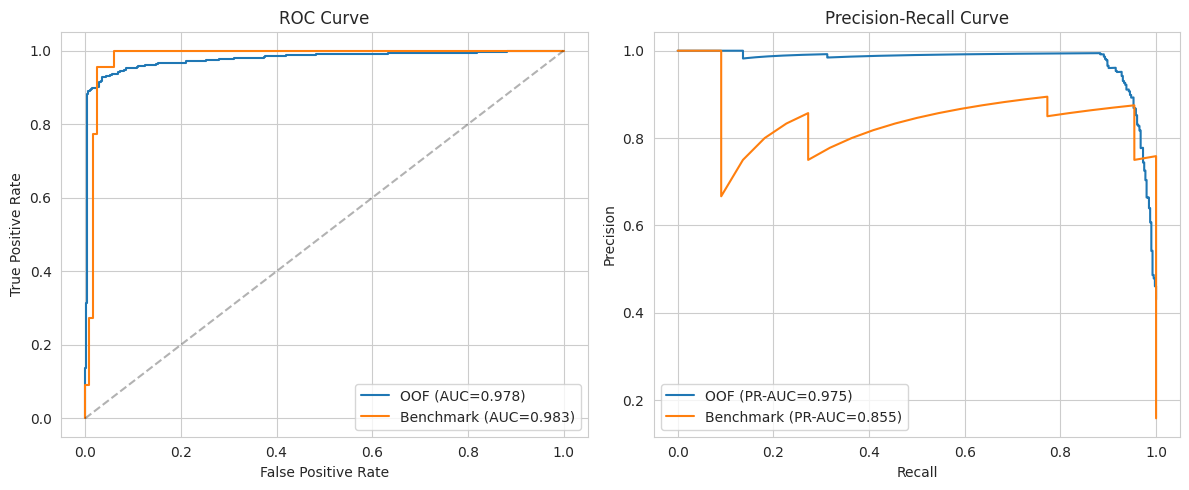

In [8]:
#@title # 8. ROC and Precision-Recall curves (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_oof, tpr_oof, _ = roc_curve(y_train_full, oof_proba)
fpr_bench, tpr_bench, _ = roc_curve(y_bench, y_bench_proba)
axes[0].plot(fpr_oof, tpr_oof, label=f"OOF (AUC={roc_auc_score(y_train_full, oof_proba):.3f})")
axes[0].plot(fpr_bench, tpr_bench, label=f"Benchmark (AUC={bench_metrics['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_oof, rec_oof, _ = precision_recall_curve(y_train_full, oof_proba)
prec_bench, rec_bench, _ = precision_recall_curve(y_bench, y_bench_proba)
axes[1].plot(rec_oof, prec_oof, label=f"OOF (PR-AUC={average_precision_score(y_train_full, oof_proba):.3f})")
axes[1].plot(rec_bench, prec_bench, label=f"Benchmark (PR-AUC={bench_metrics['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "roc_pr_curves.png"), dpi=600)
plt.show()


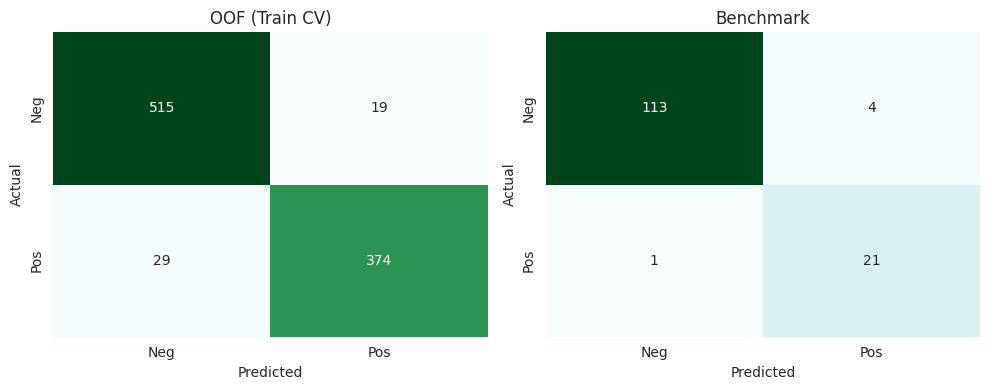

In [11]:
#@title # 9. Confusion matrix heatmaps (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_oof = confusion_matrix(y_train_full, oof_pred)
cm_bench_ = confusion_matrix(y_bench, y_bench_pred)

for ax, cm, title in zip(axes, [cm_oof, cm_bench_], ["OOF (Train CV)", "Benchmark"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", cbar=False,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrices.png"), dpi=600)
plt.show()


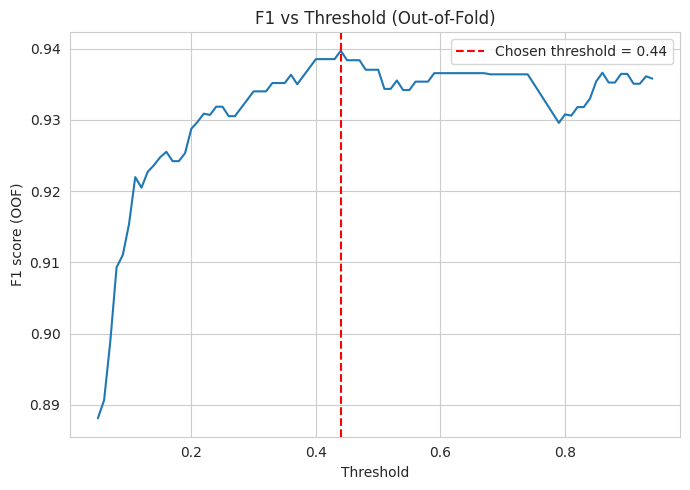

In [12]:
#@title # 10. F1 score vs threshold (OOF)
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score (OOF)")
plt.title("F1 vs Threshold (Out-of-Fold)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "f1_vs_threshold.png"), dpi=600)
plt.show()


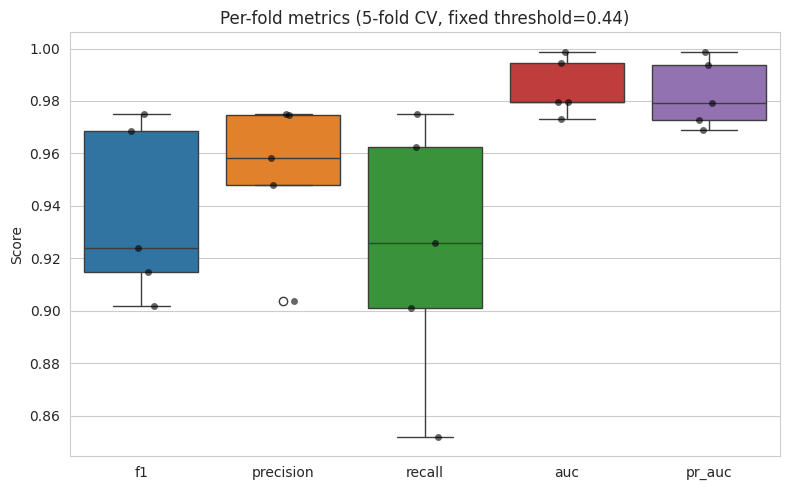

            f1  precision    recall       auc    pr_auc
mean  0.936840   0.951937  0.923302  0.985084  0.982638
std   0.032921   0.029327  0.049518  0.010959  0.012998


In [13]:
#@title # 11. Per-fold metrics with best hyperparameters (multi-metric)
# Unlike Model #1-6 (which cheaply retrain a tabular model per fold here),
# GNN fold-level metrics were already captured during the OOF pass in
# section 5 to avoid a third expensive round of training -- this cell only
# visualizes them.

plt.figure(figsize=(8, 5))
sns.boxplot(data=fold_metrics_df)
sns.stripplot(data=fold_metrics_df, color="black", size=5, alpha=0.6)
plt.ylabel("Score")
plt.title(f"Per-fold metrics ({N_FOLDS}-fold CV, fixed threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics_boxplot.png"), dpi=600)
plt.show()

print(fold_metrics_df.describe().loc[["mean", "std"]])


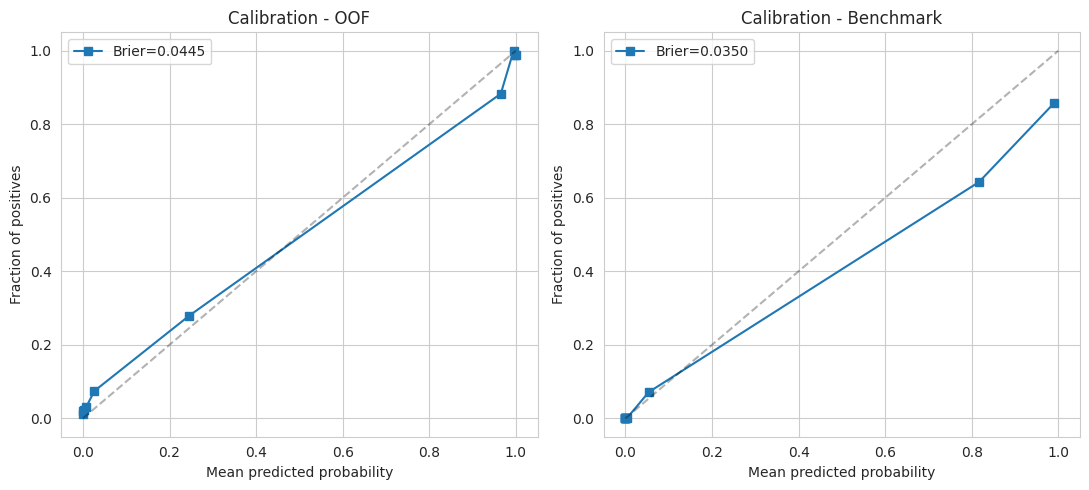

In [14]:
#@title # 12. Calibration curve & Brier score
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, proba, y_true, title in zip(
    axes, [oof_proba, y_bench_proba], [y_train_full, y_bench], ["OOF", "Benchmark"]
):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", label=f"Brier={brier_score_loss(y_true, proba):.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration - {title}")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "calibration_curves.png"), dpi=600)
plt.show()


False Positives: 4
                                   sequence  pred_proba  seq_len
MTLTSTLRRQTRTTATATVLAAAAALALCAAPASAQQTGP...    0.996183      293
MHLPRSRWDIPFKEETTMTHHFSVRALLAAGALLASAAVS...    0.970876      304
MFQRVWALTAALMLMLSLGATSSHAAQNPHERGPDPSNSY...    0.987227      284
MLVNGQHYHLTAAISGEKPALLMLHGFTGTSETFQDSISG...    0.936616      275

False Negatives: 1
                                   sequence  pred_proba  seq_len
MVRVFGLTLLALLVPALAAPVPEDLEARQSGCADVMVVYA...    0.129231      203


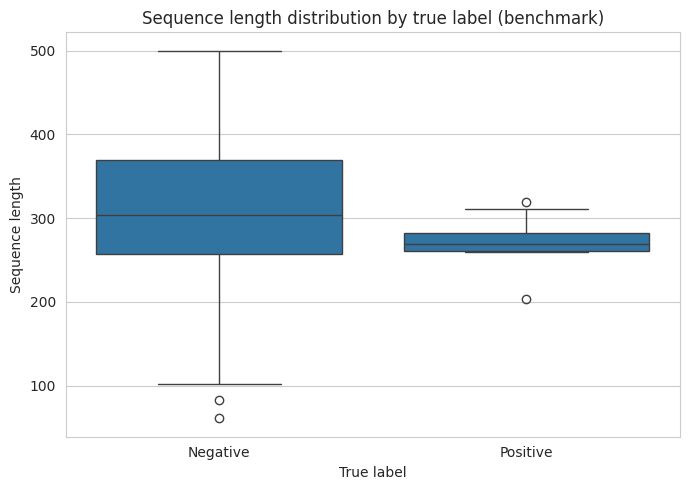

In [15]:
#@title # 13. Error analysis on the benchmark set
df_bench_result = pd.DataFrame({
    "id": bench_ids,
    "sequence": [artifacts[i]["sequence"] for i in bench_ids],
    "label": y_bench,
    "pred_proba": y_bench_proba,
    "pred_label": y_bench_pred,
})
df_bench_result["seq_len"] = df_bench_result["sequence"].str.len()

false_pos = df_bench_result[(df_bench_result["label"] == 0) & (df_bench_result["pred_label"] == 1)]
false_neg = df_bench_result[(df_bench_result["label"] == 1) & (df_bench_result["pred_label"] == 0)]

print(f"False Positives: {len(false_pos)}")
print(false_pos[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

print(f"\nFalse Negatives: {len(false_neg)}")
print(false_neg[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

df_bench_result.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_predictions_detailed.csv"), index=False)

plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y="seq_len", data=df_bench_result)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.xlabel("True label")
plt.ylabel("Sequence length")
plt.title("Sequence length distribution by true label (benchmark)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "seq_len_by_label.png"), dpi=600)
plt.show()


In [16]:
#@title # 14. Bootstrap confidence intervals for benchmark metrics
# The benchmark set is small, so point estimates alone can be misleading.
# Bootstrap resampling gives a 95% CI for each metric.

def bootstrap_metric(y_true, values, metric_fn, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], values[idx]))
    return np.mean(scores), np.percentile(scores, [2.5, 97.5])

metrics_to_bootstrap = {
    "f1": (f1_score, y_bench_pred),
    "precision": (precision_score, y_bench_pred),
    "recall": (recall_score, y_bench_pred),
    "auc": (roc_auc_score, y_bench_proba),
    "pr_auc": (average_precision_score, y_bench_proba),
}

print("Benchmark metrics with 95% bootstrap CI (n_boot=2000):")
ci_results = {}
for name, (fn, vals) in metrics_to_bootstrap.items():
    mean, (lo, hi) = bootstrap_metric(y_bench, vals, fn)
    ci_results[name] = {"mean": mean, "ci_low": lo, "ci_high": hi}
    print(f"  {name:<10}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

pd.DataFrame(ci_results).T.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics_bootstrap_ci.csv"))


Benchmark metrics with 95% bootstrap CI (n_boot=2000):
  f1        : 0.8917  [0.7857, 0.9767]
  precision : 0.8411  [0.6875, 0.9643]
  recall    : 0.9535  [0.8333, 1.0000]
  auc       : 0.9824  [0.9586, 0.9990]
  pr_auc    : 0.8638  [0.6819, 0.9955]


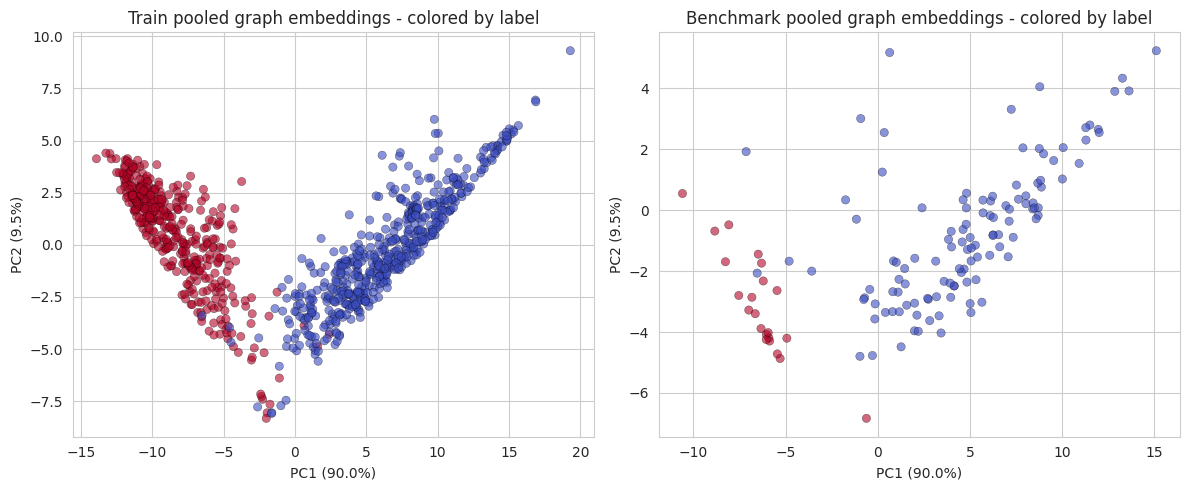

In [17]:
#@title # 15. PCA visualization of graph-level pooled embeddings
# Unlike Model #1-6 (PCA on the raw input representation), here we PCA the
# GNN's LEARNED graph-level embedding (output of the conv layers + mean
# pooling, before the final classifier head) -- i.e. what the model itself
# has learned to represent each protein as, not the raw ESM-2 input.

@torch.no_grad()
def get_pooled_embeddings(model, ids, edge_key, batch_size=BATCH_SIZE):
    model.eval()
    loader = DataLoader(make_data_list(ids, edge_key), batch_size=batch_size, shuffle=False)
    embs = []
    for batch in loader:
        batch = batch.to(device)
        pooled = model.pool_embedding(batch.x, batch.edge_index, batch.batch)
        embs.append(pooled.cpu().numpy())
    return np.vstack(embs)

train_pooled = get_pooled_embeddings(final_model, train_ids_all, EDGE_KEY)
bench_pooled = get_pooled_embeddings(final_model, bench_ids, EDGE_KEY)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(train_pooled)
X_bench_pca = pca.transform(bench_pooled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_pca, y, title in zip(axes, [X_train_pca, X_bench_pca], [y_train_full, y_bench], ["Train", "Benchmark"]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{title} pooled graph embeddings - colored by label")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "embedding_pca.png"), dpi=600)
plt.show()


Additivity sanity check -- mean|gap|=0.7209, logit scale (std)=10.6234
shap_values_pos shape: (300, 64)


/tmp/ipykernel_935/1346203800.py:59: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, train_pooled[sample_idx], show=False, max_display=20)


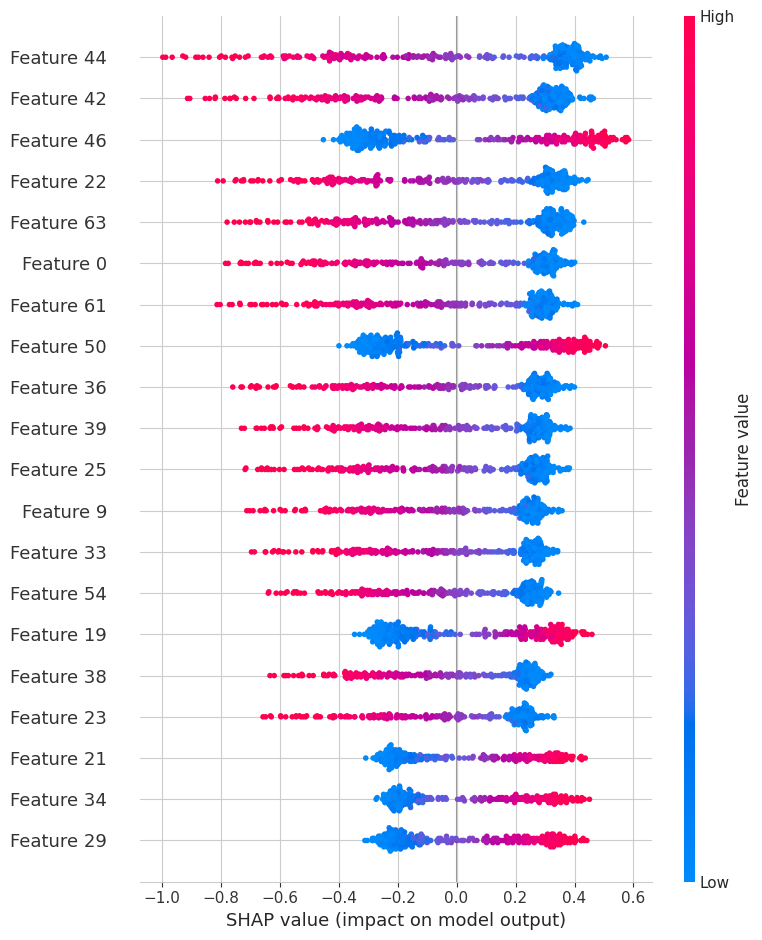

 pooled_embedding_dim  mean_abs_shap
                   44       0.362043
                   42       0.319529
                   46       0.313966
                   22       0.309041
                   63       0.305131
                    0       0.293116
                   61       0.284978
                   50       0.280741
                   36       0.277521
                   39       0.267374
                   25       0.265427
                    9       0.249847
                   33       0.249802
                   54       0.238318
                   19       0.237660
                   38       0.229892
                   23       0.225216
                   21       0.218347
                   34       0.213732
                   29       0.213464


In [18]:
#@title # 16. SHAP analysis - pooled-embedding level (model diagnostics)
# TreeExplainer (used in Model #1-6) does not apply to a neural network.
# Instead, we treat the GNN's classifier HEAD (fc1 -> ReLU -> fc2) as a
# small feed-forward network taking the pooled graph embedding as input,
# and explain THAT with shap.GradientExplainer. This mirrors the diagnostic
# framing used for ESM-2/ProtT5 embedding dimensions in Model #1-4: pooled
# embedding dimensions are not individually human-readable, so this is a
# MODEL DIAGNOSTIC (is the classifier head relying on a handful of
# dominant pooled dimensions, or spread across many?), not a biological
# interpretation. For biological interpretation, see the in-silico
# mutagenesis scan in the next cell.

class ClassifierHead(nn.Module):
    """Wraps fc1 -> ReLU -> fc2 (dropout disabled) so SHAP can treat the
    pooled embedding as a plain tabular input."""
    def __init__(self, gnn_model):
        super().__init__()
        self.fc1 = gnn_model.fc1
        self.fc2 = gnn_model.fc2

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

head = ClassifierHead(final_model).to(device).eval()

background = torch.tensor(train_pooled[np.random.choice(len(train_pooled), min(100, len(train_pooled)), replace=False)],
                           dtype=torch.float32).to(device)

# GradientExplainer (expected-gradients) instead of DeepExplainer: it does
# not rely on layer-by-layer hooks matching every op in the graph exactly,
# so it is more robust for less-common architectures and does not carry
# DeepExplainer's strict additivity assertion (which can fail hard on
# some PyTorch graphs even when the underlying attributions are sound).
explainer = shap.GradientExplainer(head, background)

sample_idx = np.random.choice(len(train_pooled), min(300, len(train_pooled)), replace=False)
sample_input = torch.tensor(train_pooled[sample_idx], dtype=torch.float32).to(device)

try:
    shap_values = explainer.shap_values(sample_input, check_additivity=False)
except TypeError:
    shap_values = explainer.shap_values(sample_input)

shap_values_pos = shap_values[0] if isinstance(shap_values, list) else shap_values
shap_values_pos = np.asarray(shap_values_pos).reshape(len(sample_idx), -1)

# Sanity check: mean |sum(shap) - (f(x) - f(background))| should be small
# relative to the scale of the model's output logits.
with torch.no_grad():
    f_x = head(sample_input).cpu().numpy().reshape(-1)
    f_base = head(background).cpu().numpy().mean()
shap_sum = shap_values_pos.sum(axis=1)
gap = np.abs(shap_sum - (f_x - f_base))
print(f"Additivity sanity check -- mean|gap|={gap.mean():.4f}, logit scale (std)={f_x.std():.4f}")

print(f"shap_values_pos shape: {shap_values_pos.shape}")

plt.figure()
shap.summary_plot(shap_values_pos, train_pooled[sample_idx], show=False, max_display=20)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "shap_summary_pooled_embedding.png"), dpi=600, bbox_inches="tight")
plt.show()

mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_dims = np.argsort(mean_abs_shap)[::-1][:20]

importance_df = pd.DataFrame({
    "pooled_embedding_dim": top_dims,
    "mean_abs_shap": mean_abs_shap[top_dims],
})
print(importance_df.to_string(index=False))
importance_df.to_csv(os.path.join(MODEL_OUT_DIR, "shap_top_embedding_dims.csv"), index=False)


Fetching IsPETase (A0A0K8P6T7) from UniProt...
  Length: 290 aa
  Base predicted probability: 0.9938
  Known catalytic triad: [160, 206, 237]
    position 160: rank 265/290 (top 91.4%), delta=-0.00059
    position 206: rank 225/290 (top 77.6%), delta=-0.00013
    position 237: rank 50/290 (top 17.2%), delta=0.00067
  Top-15 predicted important positions: [17, 54, 70, 76, 83, 101, 106, 107, 159, 174, 192, 193, 217, 257, 265]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_ispetase_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_ispetase_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 position residue  alanine_delta  mask_delta
      160       S      -0.000589   -0.000294
      206       D      -0.000135    0.000191
      237       

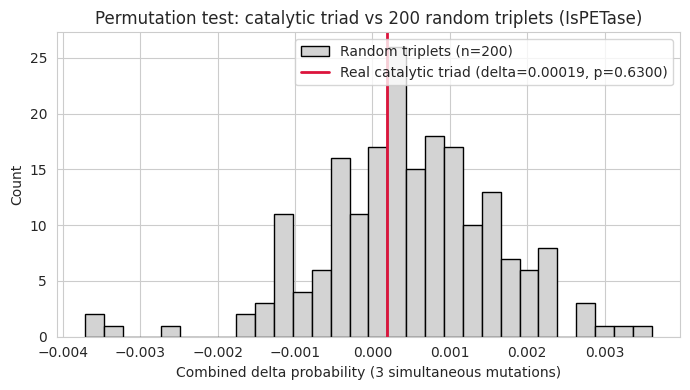


  Running windowed mutagenesis scan (window_size=7)... this runs ~290 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 160: window-rank 59/290 (top 20.3%), window_delta=0.00374 (vs single-residue delta=-0.00059)
    position 206: window-rank 219/290 (top 75.5%), window_delta=-0.00032 (vs single-residue delta=-0.00013)
    position 237: window-rank 145/290 (top 50.0%), window_delta=0.00112 (vs single-residue delta=0.00067)


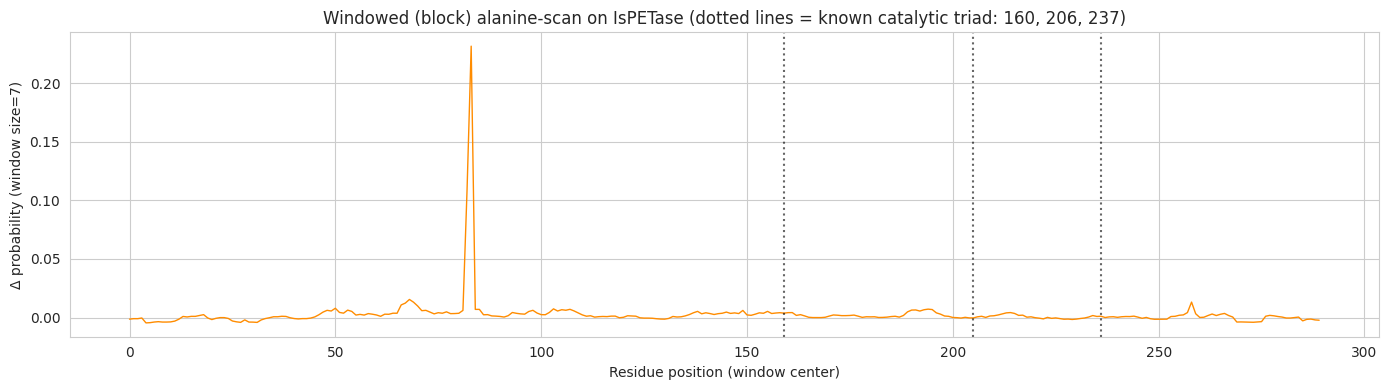

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_ispetase_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_ispetase_windowed_scan.csv


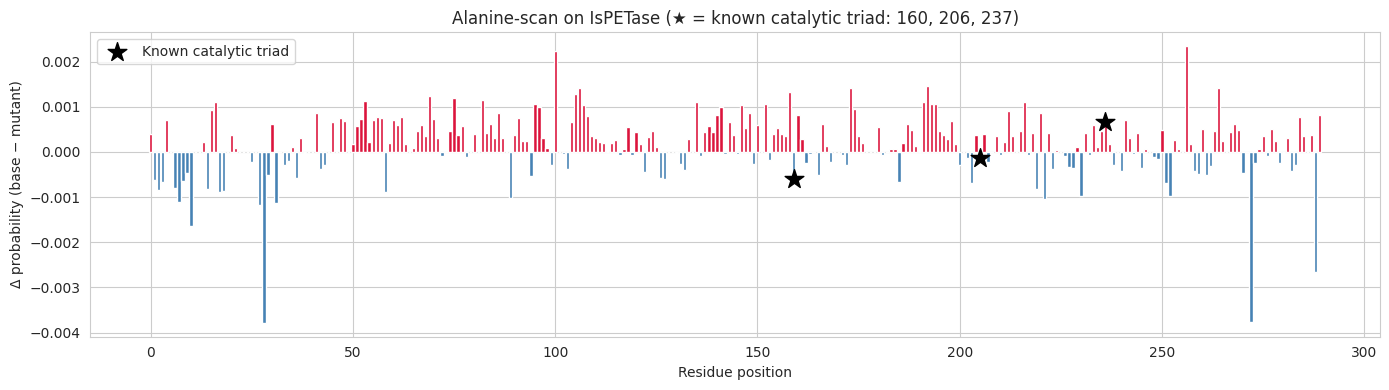

Fetching LCC (G9BY57) from UniProt...
  Length: 293 aa
  Base predicted probability: 0.9992
  Known catalytic triad: [165, 210, 242]
    position 165: rank 220/293 (top 75.1%), delta=-0.00002
    position 210: rank 249/293 (top 85.0%), delta=-0.00004
    position 242: rank 108/293 (top 36.9%), delta=0.00005
  Top-15 predicted important positions: [1, 3, 6, 7, 8, 30, 36, 78, 114, 115, 158, 179, 259, 267, 274]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_lcc_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_lcc_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 position residue  alanine_delta  mask_delta
      165       S      -0.000017    0.000036
      210       D      -0.000045    0.000023
      242       H       0.000048    0.0000

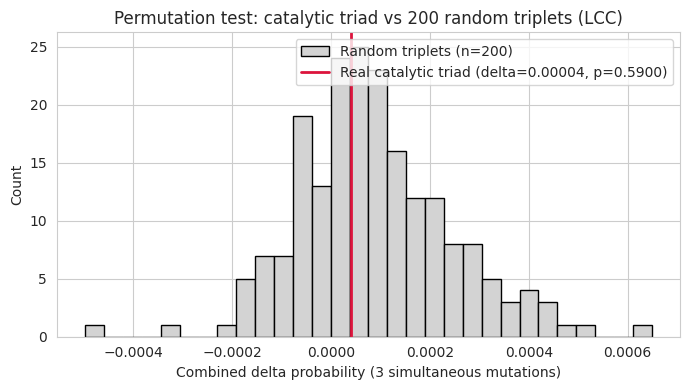


  Running windowed mutagenesis scan (window_size=7)... this runs ~293 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 165: window-rank 188/293 (top 64.2%), window_delta=0.00003 (vs single-residue delta=-0.00002)
    position 210: window-rank 259/293 (top 88.4%), window_delta=-0.00017 (vs single-residue delta=-0.00004)
    position 242: window-rank 200/293 (top 68.3%), window_delta=-0.00000 (vs single-residue delta=0.00005)


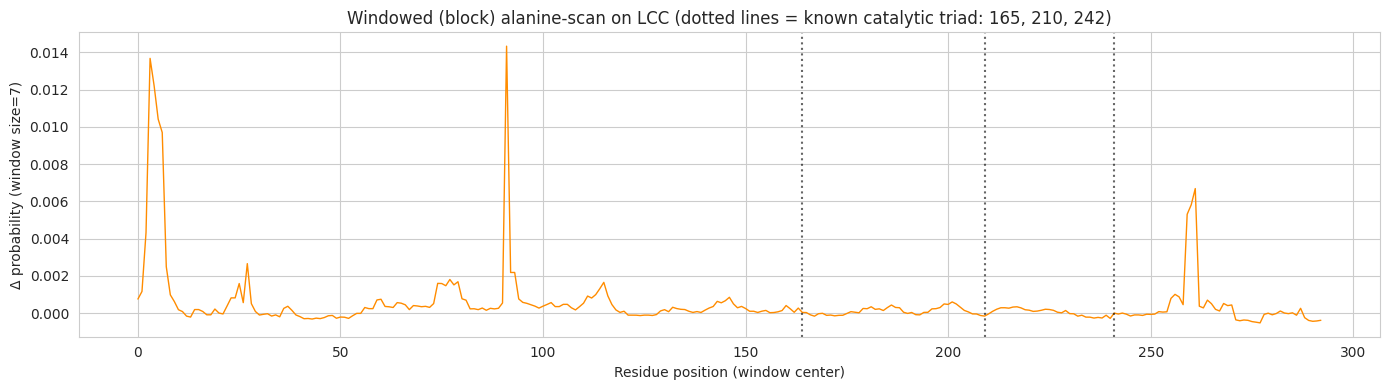

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_lcc_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_lcc_windowed_scan.csv


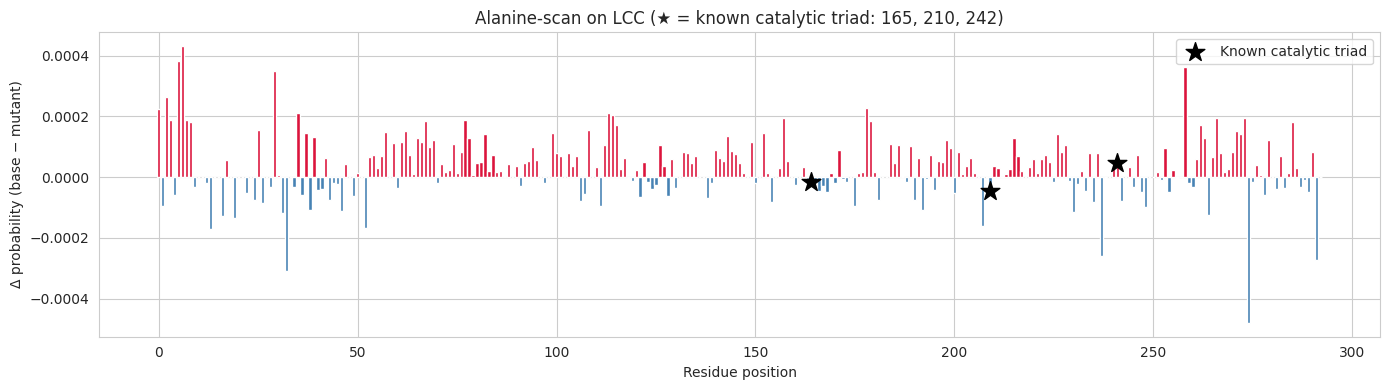

Fetching CalB_negative_control (P41365) from UniProt...
  Length: 342 aa
  Base predicted probability: 0.2258
  Known catalytic triad: [130, 212, 249]
    position 130: rank 116/342 (top 33.9%), delta=0.03495
    position 212: rank 50/342 (top 14.6%), delta=0.06077
    position 249: rank 2/342 (top 0.6%), delta=0.12681
  Top-15 predicted important positions: [11, 25, 78, 91, 120, 131, 134, 180, 201, 208, 249, 295, 303, 310, 336]
  Overlap with catalytic triad (top-15): [249] (1/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_calb_negative_control_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_calb_negative_control_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 position residue  alanine_delta  mask_delta
      130       S       0.034949   -0.011365
      212       D       0.0

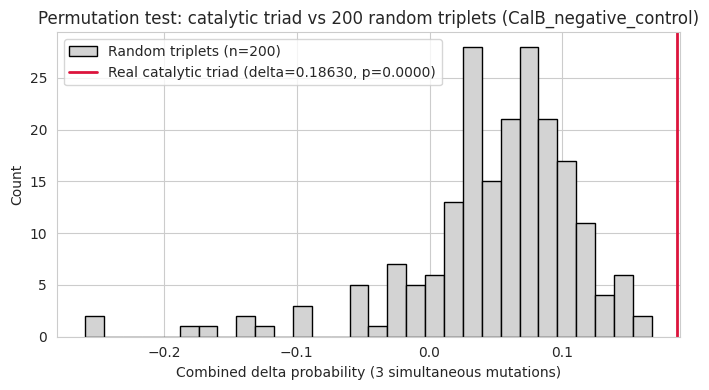


  Running windowed mutagenesis scan (window_size=7)... this runs ~342 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 130: window-rank 17/342 (top 5.0%), window_delta=0.21452 (vs single-residue delta=0.03495)
    position 212: window-rank 42/342 (top 12.3%), window_delta=0.19775 (vs single-residue delta=0.06077)
    position 249: window-rank 84/342 (top 24.6%), window_delta=0.18156 (vs single-residue delta=0.12681)


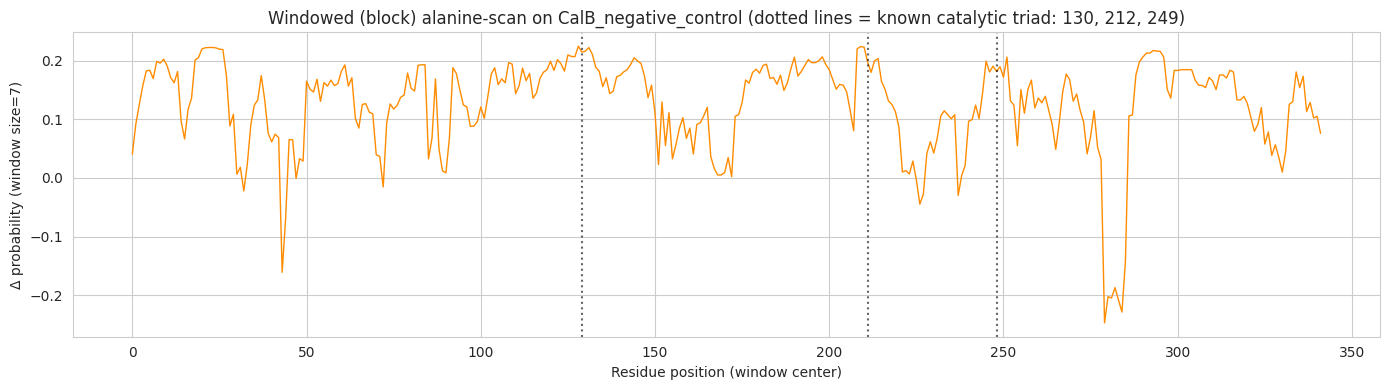

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_calb_negative_control_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_calb_negative_control_windowed_scan.csv


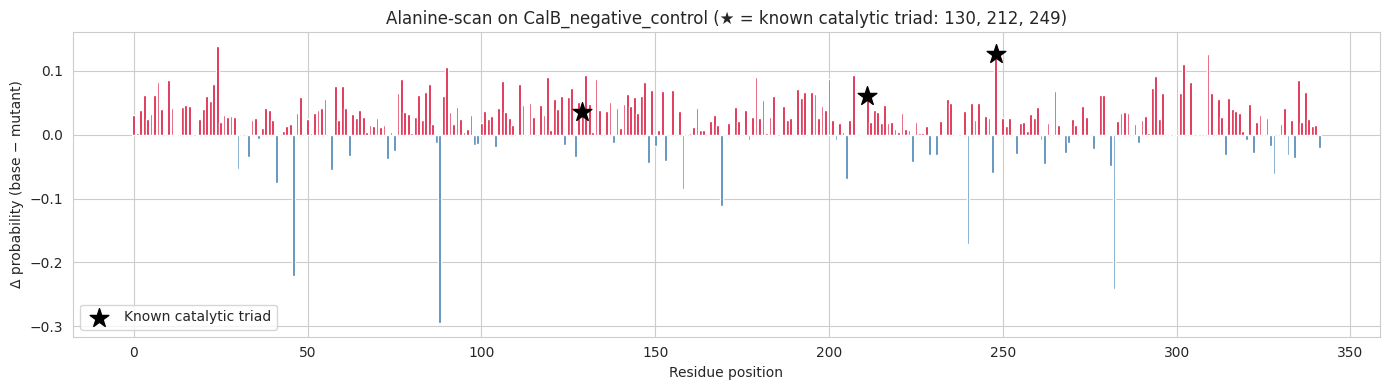


Saved reference scan results to /content/drive/MyDrive/InterPET/models/model7_1d_graph_chain/reference_mutagenesis_results.pkl


In [9]:
#@title # 17. Fixed reference-sequence scan -- IsPETase active site (valid cross-model comparison)
# Mirrors Model #1's section 17: scan a FIXED reference sequence, chosen
# independently of any model's predictions, with a catalytic site already
# confirmed in the literature: IsPETase (Ideonella sakaiensis PETase),
# UniProt A0A0K8P6T7.
#
#   Catalytic triad: Ser160, Asp206, His237
#   (Yoshida et al. 2016, Science; Han et al. 2017, Nat. Commun., PDB 5XJH --
#   confirmed structurally and by site-directed mutagenesis; any substitution
#   at these positions abolishes catalytic activity.)
#
# Because every model notebook scans this exact same sequence, the top
# residues each model highlights can be directly compared, and checked
# against a real, experimentally-confirmed active site -- not just against
# each other. For Model #7, "mutating" a position means: substitute the
# residue, re-embed the FULL sequence with ESM-2 (per-residue), rebuild a
# chain-edge graph from the mutated sequence, and re-run the GNN.

!pip install -q openpyxl
import requests


@torch.no_grad()
def build_graph_for_sequence(sequence, edge_key=EDGE_KEY):
    node_emb, seq_used = get_per_residue_embedding(sequence)
    L = len(seq_used)
    if edge_key == "edge_index_chain":
        src = list(range(L - 1)) + list(range(1, L))
        dst = list(range(1, L)) + list(range(L - 1))
        edge_index = torch.tensor([src, dst], dtype=torch.long)
    else:
        raise ValueError("Model #7 only supports chain edges.")
    return Data(x=node_emb, edge_index=edge_index), seq_used


@torch.no_grad()
def predict_single(model, data):
    data = data.to(device)
    batch = torch.zeros(data.x.shape[0], dtype=torch.long, device=device)
    logit = model(data.x, data.edge_index, batch)
    return float(1 / (1 + np.exp(-logit.item())))


def mutagenesis_scan(sequence, model, mutate_to="A"):
    """Return (base_proba, per_position_deltas) for a single sequence.
    delta[i] = base_proba - proba_after_mutating_position_i_to_`mutate_to`.
    A positive delta means residue i supports the positive-class prediction."""
    seq = sequence.strip().upper()
    base_data, seq_used = build_graph_for_sequence(seq)
    base_proba = predict_single(model, base_data)

    deltas = np.zeros(len(seq_used))
    for i, aa in enumerate(seq_used):
        if aa == mutate_to:
            deltas[i] = 0.0
            continue
        mutant_seq = seq_used[:i] + mutate_to + seq_used[i + 1:]
        mutant_data, _ = build_graph_for_sequence(mutant_seq)
        mutant_proba = predict_single(model, mutant_data)
        deltas[i] = base_proba - mutant_proba

    return base_proba, deltas


def windowed_mutagenesis_scan(sequence, model, window_size=7, mutate_to="A"):
    """Slide a contiguous window across the sequence, mutating the WHOLE
    window to alanine at once (rather than one residue at a time), and
    record the resulting delta at the window's center position.
    This can reveal regions that matter collectively even when no single
    residue inside them stands out on its own (i.e. individual mutations
    are below the mean-pooling noise floor, but a whole disrupted block
    is not)."""
    seq = sequence.strip().upper()
    n = len(seq)
    half = window_size // 2

    base_data, seq_used = build_graph_for_sequence(seq)
    base_proba = predict_single(model, base_data)

    window_deltas = np.zeros(n)
    for center in range(n):
        start = max(0, center - half)
        end = min(n, center + half + 1)
        mutant_seq = seq[:start] + mutate_to * (end - start) + seq[end:]
        mutant_data, _ = build_graph_for_sequence(mutant_seq)
        mutant_proba = predict_single(model, mutant_data)
        window_deltas[center] = base_proba - mutant_proba

    return base_proba, window_deltas


REFERENCE_SEQUENCES = {
    "IsPETase": {
        "uniprot_id": "A0A0K8P6T7",
        "source": "Yoshida et al. 2016 Science; Han et al. 2017 Nat Commun (PDB 5XJH)",
        "catalytic_triad_positions": [160, 206, 237],  # Ser160, Asp206, His237 (1-indexed)
        "expected_residues": {160: "S", 206: "D", 237: "H"},
        "is_petase": True,
    },
    "LCC": {
        "uniprot_id": "G9BY57",
        "source": "Sulaiman et al. 2012 Appl Environ Microbiol; Tournier et al. 2020 Nature (PDB 4EB0)",
        "catalytic_triad_positions": [165, 210, 242],  # Ser165, Asp210, His242 (1-indexed)
        "expected_residues": {165: "S", 210: "D", 242: "H"},
        "is_petase": True,
    },
    "CalB_negative_control": {
        "uniprot_id": "P41365",
        "source": "Uppenberg et al. 1994 Structure (PDB 1TCA) -- Candida antarctica Lipase B, "
                   "NOT PET-active; same catalytic mechanism/fold family as PETases, used as "
                   "a functional-specificity negative control",
        "catalytic_triad_positions": [130, 212, 249],  # Ser130, Asp212, His249 (1-indexed)
        "expected_residues": {130: "S", 212: "D", 249: "H"},
        "is_petase": False,
    },
}


def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    lines = resp.text.strip().split("\n")
    return "".join(lines[1:])  # drop the ">header" line


@torch.no_grad()
def predict_with_masked_position(sequence, pos_1indexed, model, max_len=MAX_SEQ_LEN):
    """Like predict_single, but the residue at `pos_1indexed` is replaced
    with ESM-2's native <mask> token BEFORE embedding (instead of the
    literal alanine substitution used everywhere else in this section)."""
    seq = sequence[:max_len]
    inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    masked_ids = inputs["input_ids"].clone()
    masked_ids[0, pos_1indexed] = esm2_tokenizer.mask_token_id  # index 0 is <cls>, so residue `pos` sits at token index `pos`
    out = esm2_model(input_ids=masked_ids, attention_mask=inputs["attention_mask"])
    hidden = out.last_hidden_state[0]
    residue_emb = hidden[1:1 + len(seq)].cpu()

    L = len(seq)
    src_idx = list(range(L - 1)) + list(range(1, L))
    dst_idx = list(range(1, L)) + list(range(L - 1))
    edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
    data = Data(x=residue_emb, edge_index=edge_index)
    return predict_single(model, data)


reference_scan_results = {}

for ref_name, ref_info in REFERENCE_SEQUENCES.items():
    print(f"Fetching {ref_name} ({ref_info['uniprot_id']}) from UniProt...")
    ref_seq = fetch_uniprot_sequence(ref_info["uniprot_id"])
    print(f"  Length: {len(ref_seq)} aa")

    base_p, deltas = mutagenesis_scan(ref_seq, final_model)
    print(f"  Base predicted probability: {base_p:.4f}")

    top_n = 15
    order = np.argsort(deltas)[::-1]
    top_positions = set((order[:top_n] + 1).tolist())  # 1-indexed
    known_positions = set(ref_info["catalytic_triad_positions"])
    overlap = known_positions & top_positions

    rank_of = {pos: int(np.where(order == (pos - 1))[0][0]) + 1 for pos in known_positions}
    n_total = len(deltas)
    print(f"  Known catalytic triad: {sorted(known_positions)}")
    for pos in sorted(known_positions):
        pct_from_top = 100 * rank_of[pos] / n_total
        print(f"    position {pos}: rank {rank_of[pos]}/{n_total} (top {pct_from_top:.1f}%), delta={deltas[pos-1]:.5f}")
    print(f"  Top-{top_n} predicted important positions: {sorted(top_positions)}")
    print(f"  Overlap with catalytic triad (top-{top_n}): {sorted(overlap)} ({len(overlap)}/{len(known_positions)})")

    # ---- Export full per-residue delta table to Excel + CSV ----
    full_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("delta_proba", ascending=False).reset_index(drop=True)

    excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.xlsx")
    csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.csv")
    full_scan_df.to_excel(excel_path, index=False, sheet_name="alanine_scan")
    full_scan_df.to_csv(csv_path, index=False)
    print(f"  Saved full per-residue delta table to {excel_path}")
    print(f"  Saved full per-residue delta table to {csv_path}")

    # ---- Variation 1: mask-token substitution vs alanine, at the 3 known positions only ----
    mask_comparison = []
    for pos in sorted(known_positions):
        mask_proba = predict_with_masked_position(ref_seq, pos, final_model)
        mask_delta = base_p - mask_proba
        mask_comparison.append({
            "position": pos,
            "residue": ref_seq[pos - 1],
            "alanine_delta": deltas[pos - 1],
            "mask_delta": mask_delta,
        })

    mask_comparison_df = pd.DataFrame(mask_comparison)
    print("\n  Alanine substitution vs native <mask> substitution (catalytic triad only):")
    print(mask_comparison_df.to_string(index=False))

    # ---- Variation 2: combined (simultaneous) triple mutation vs sum of individual deltas ----
    seq_list = list(ref_seq)
    for pos in known_positions:
        seq_list[pos - 1] = "A"
    combined_mutant_seq = "".join(seq_list)
    combined_data, _ = build_graph_for_sequence(combined_mutant_seq)
    combined_proba = predict_single(final_model, combined_data)
    combined_delta = base_p - combined_proba
    sum_individual_deltas = sum(deltas[pos - 1] for pos in known_positions)

    print(f"\n  Combined triple-mutation (all 3 catalytic residues -> Ala simultaneously):")
    print(f"    proba after combined mutation : {combined_proba:.4f}")
    print(f"    combined delta                : {combined_delta:.5f}")
    print(f"    sum of individual deltas       : {sum_individual_deltas:.5f}")
    print(f"    synergy (combined - sum)        : {combined_delta - sum_individual_deltas:.5f}")

    # ---- Variation 2b: permutation test for the combined-mutation synergy ----
    # Is the combined delta actually special, or would mutating ANY random
    # triplet of positions simultaneously tend to produce a similarly large
    # delta (since disturbing 3 positions at once is inherently a bigger
    # perturbation than disturbing 1)? We build a null distribution from
    # random triplets (excluding the real triad) and see where the real
    # triad's combined delta falls within it.
    n_permutations = 200
    rng = np.random.default_rng(RANDOM_SEED)
    all_positions = np.arange(1, len(ref_seq) + 1)
    candidate_positions = np.setdiff1d(all_positions, list(known_positions))

    null_deltas = np.zeros(n_permutations)
    for p_i in range(n_permutations):
        rand_positions = rng.choice(candidate_positions, size=len(known_positions), replace=False)
        seq_list_rand = list(ref_seq)
        for pos in rand_positions:
            seq_list_rand[pos - 1] = "A"
        rand_mutant_seq = "".join(seq_list_rand)
        rand_data, _ = build_graph_for_sequence(rand_mutant_seq)
        rand_proba = predict_single(final_model, rand_data)
        null_deltas[p_i] = base_p - rand_proba
        if (p_i + 1) % 50 == 0:
            print(f"    permutation {p_i + 1}/{n_permutations}...")

    p_value = float(np.mean(null_deltas >= combined_delta))
    z_score = float((combined_delta - null_deltas.mean()) / (null_deltas.std() + 1e-12))

    print(f"\n  Permutation test (n={n_permutations} random triplets of positions, "
          f"excluding the real catalytic triad):")
    print(f"    null distribution -- mean={null_deltas.mean():.5f}, std={null_deltas.std():.5f}, "
          f"max={null_deltas.max():.5f}")
    print(f"    observed combined delta (real catalytic triad): {combined_delta:.5f}")
    print(f"    empirical p-value (P[null >= observed]): {p_value:.4f}")
    print(f"    z-score: {z_score:.3f}")

    plt.figure(figsize=(7, 4))
    plt.hist(null_deltas, bins=30, color="lightgray", edgecolor="black", label=f"Random triplets (n={n_permutations})")
    plt.axvline(combined_delta, color="crimson", linewidth=2,
                label=f"Real catalytic triad (delta={combined_delta:.5f}, p={p_value:.4f})")
    plt.xlabel("Combined delta probability (3 simultaneous mutations)")
    plt.ylabel("Count")
    plt.title(f"Permutation test: catalytic triad vs {n_permutations} random triplets ({ref_name})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_test.png"), dpi=600)
    plt.show()

    pd.DataFrame({"null_delta": null_deltas}).to_csv(
        os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_null.csv"), index=False
    )

    # ---- Variation 3: windowed/block mutagenesis ----
    window_size = 7
    print(f"\n  Running windowed mutagenesis scan (window_size={window_size})... "
          f"this runs ~{len(ref_seq)} more forward passes, so it takes a bit.")
    _, window_deltas = windowed_mutagenesis_scan(ref_seq, final_model, window_size=window_size)

    window_order = np.argsort(window_deltas)[::-1]
    print(f"  Window-centered rank of catalytic positions (window_size={window_size}):")
    for pos in sorted(known_positions):
        w_rank = int(np.where(window_order == (pos - 1))[0][0]) + 1
        w_pct = 100 * w_rank / n_total
        print(f"    position {pos}: window-rank {w_rank}/{n_total} (top {w_pct:.1f}%), "
              f"window_delta={window_deltas[pos-1]:.5f} (vs single-residue delta={deltas[pos-1]:.5f})")

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(window_deltas)), window_deltas, color="darkorange", linewidth=1)
    for pos in known_positions:
        plt.axvline(pos - 1, color="black", linestyle=":", alpha=0.6)
    plt.xlabel("Residue position (window center)")
    plt.ylabel(f"Δ probability (window size={window_size})")
    plt.title(f"Windowed (block) alanine-scan on {ref_name} "
              f"(dotted lines = known catalytic triad: {', '.join(str(p) for p in sorted(known_positions))})")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed.png"), dpi=600)
    plt.show()

    window_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "window_delta_proba": window_deltas,
        "single_residue_delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("window_delta_proba", ascending=False).reset_index(drop=True)
    window_excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.xlsx")
    window_csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.csv")
    window_scan_df.to_excel(window_excel_path, index=False, sheet_name=f"window{window_size}_scan")
    window_scan_df.to_csv(window_csv_path, index=False)
    print(f"  Saved windowed scan table to {window_excel_path}")
    print(f"  Saved windowed scan table to {window_csv_path}")

    reference_scan_results[ref_name] = {
        "sequence": ref_seq,
        "base_proba": base_p,
        "deltas": deltas,
        "window_deltas": window_deltas,
        "window_size": window_size,
        "top_positions": sorted(top_positions),
        "known_catalytic_triad": sorted(known_positions),
        "overlap_with_catalytic_triad": sorted(overlap),
        "rank_of_known_positions": rank_of,
        "mask_vs_alanine_comparison": mask_comparison,
        "combined_triple_mutation_delta": combined_delta,
        "sum_of_individual_deltas": sum_individual_deltas,
        "permutation_test_null_deltas": null_deltas,
        "permutation_test_p_value": p_value,
        "permutation_test_z_score": z_score,
    }

    plt.figure(figsize=(14, 4))
    colors = ["crimson" if d > 0 else "steelblue" for d in deltas]
    plt.bar(range(len(deltas)), deltas, color=colors)
    for pos in known_positions:
        plt.scatter([pos - 1], [deltas[pos - 1]], marker="*", s=200,
                    color="black", zorder=5,
                    label="Known catalytic triad" if pos == min(known_positions) else None)
    plt.xlabel("Residue position")
    plt.ylabel("Δ probability (base − mutant)")
    plt.title(f"Alanine-scan on {ref_name} (★ = known catalytic triad: "
              f"{', '.join(str(p) for p in sorted(known_positions))})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}.png"), dpi=600)
    plt.show()

with open(os.path.join(MODEL_OUT_DIR, "reference_mutagenesis_results.pkl"), "wb") as f:
    pickle.dump(reference_scan_results, f)

print(f"\nSaved reference scan results to {MODEL_OUT_DIR}/reference_mutagenesis_results.pkl")


In [ ]:
#@title # 18. Top-15 residues for the top-3 highest-confidence benchmark sequences
# Mirrors Model #1's section 18. Selection criterion here is purely the
# model's own predicted probability (base_proba on the benchmark set) --
# the 3 sequences the model is most confident about, regardless of
# TP/FP/FN status. mutagenesis_scan() and build_graph_for_sequence() were
# already defined in the previous section, so they're reused as-is here.

top3_rows = np.argsort(y_bench_proba)[::-1][:3]
top3_ids = [bench_ids[r] for r in top3_rows]
print(f"Top-3 benchmark ids by base_proba: {top3_ids}")

excel_path = os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.xlsx")
top15_summary = []

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for seq_id in top3_ids:
        seq = artifacts[seq_id]["sequence"]
        base_p, deltas = mutagenesis_scan(seq, final_model)

        top15_idx = np.argsort(deltas)[::-1][:15]
        row_df = pd.DataFrame({
            "position": top15_idx + 1,  # 1-indexed
            "residue": [seq[i] for i in top15_idx],
            "delta_proba": deltas[top15_idx],
        })
        row_df.insert(0, "benchmark_id", seq_id)
        row_df.insert(1, "base_proba", base_p)

        sheet_name = f"id_{seq_id}"[:31]  # Excel sheet name limit
        row_df.to_excel(writer, index=False, sheet_name=sheet_name)
        top15_summary.append(row_df)

        print(f"\nId {seq_id} (base_proba={base_p:.4f}) -- top 15 residues:")
        print(row_df[["position", "residue", "delta_proba"]].to_string(index=False))

print(f"\nSaved top-15 tables for top-3 benchmark sequences to {excel_path}")

top15_summary_df = pd.concat(top15_summary, ignore_index=True)
top15_summary_df.to_csv(os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.csv"), index=False)


Top-3 benchmark ids by base_proba: [np.str_('128'), np.str_('135'), np.str_('51')]

Id 128 (base_proba=0.9992) -- top 15 residues:
 position residue  delta_proba
        9       R     0.001081
      130       R     0.001033
      197       K     0.000963
       60       E     0.000910
      236       R     0.000898
       26       R     0.000797
      224       K     0.000768
      128       K     0.000743
      159       E     0.000737
      250       E     0.000689
      186       Y     0.000652
      229       K     0.000642
      234       I     0.000636
      124       I     0.000606
      106       D     0.000595

Id 135 (base_proba=0.9972) -- top 15 residues:
 position residue  delta_proba
        1       M     0.001472
      179       K     0.000930
      281       H     0.000913
      280       H     0.000819
      282       H     0.000765
      278       H     0.000693
       96       V     0.000664
      175       W     0.000659
      252       Q     0.000659
       95      